
# 作業：非監督式學習簡化練習

本作業使用 `bank-full.csv` 作為練習資料集，主題是「非監督式學習：降維與分群」。

原本教材 `5.ipynb` 包含多種降維方法、分群方法與分群評估方式。為了讓作業更適合初學者，本作業採用以下簡化策略：

| 教材知識點 | 作業處理方式 |
|---|---|
| 非監督式學習 | 保留概念說明與實作 |
| PCA 主成分分析 | 實作，並用 2 維視覺化檢視資料分布 |
| 解釋變異比例 | 實作，用圖表觀察主成分保留多少資訊 |
| Kernel PCA | 只做概念比較，不實作 |
| 分群 Clustering | 保留概念說明與實作 |
| K-means | 實作，作為代表性的分群方法 |
| Distortion / SSE | 只做概念補充，不實作 |
| Silhouette Score | 實作，作為本作業的分群評估指標 |
| 階層式分群 | 只做概念比較，不實作 |
| DBSCAN | 只做概念比較，不實作 |

## 學習目標

完成本作業後，你應該能夠：

1. 了解非監督式學習不需要目標標籤進行訓練。
2. 使用標準化處理不同尺度的數值特徵。
3. 使用 PCA 將多個特徵降到 2 維並視覺化。
4. 使用解釋變異比例觀察 PCA 保留多少資料資訊。
5. 使用 K-means 進行分群。
6. 使用 Silhouette Score 選擇較合適的群數。
7. 解釋分群結果與原始資料特徵之間的關係。



## 0. 重要提醒

請將本 notebook 與 `bank-full.csv` 放在同一個資料夾中。

本資料集原本常用於**分類任務**，目標是預測客戶是否會申購定期存款，也就是欄位 `y`。

不過，在本作業中，我們要練習的是**非監督式學習**，因此：

- 訓練 PCA 與 K-means 時，不使用 `y`。
- `y` 只會在最後拿來輔助觀察分群結果，不能當成訓練答案。


In [18]:
# 忽略警告訊息
import warnings
warnings.filterwarnings("ignore")

# 設定字型 (有內建微軟正黑體)
import matplotlib.pyplot as plt

# 設定繪圖風格與字型，確保中文顯示正常
plt.style.use('fivethirtyeight')

# 設定字型為微軟正黑體，並確保數學符號正常顯示
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]

# 確保負號和數學符號正常顯示
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

In [19]:
# ============================================================
# 1. 匯入套件
# ============================================================
# 本作業只使用 pandas、numpy、matplotlib 與 scikit-learn。
# 不使用 seaborn，避免學生環境沒有安裝。
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



## 1. 讀取資料

`bank-full.csv` 使用分號 `;` 作為欄位分隔符號，因此讀取時需要設定：

```python
sep=';'
```


In [20]:
# ============================================================
# 2. 讀取 bank-full.csv
# ============================================================

data_path = 'bank-full.csv'

df = pd.read_csv(data_path, sep=';')

print('資料筆數與欄位數：')
print(df.shape)

print('\n資料前 5 筆：')
display(df.head())


資料筆數與欄位數：
(45211, 17)

資料前 5 筆：


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



## 2. 資料集特徵說明

這份資料來自銀行電話行銷情境。每一列代表一位客戶或一次行銷接觸紀錄。

注意：雖然資料中有 `y` 欄位，但本作業是非監督式學習，所以 `y` 不會拿來訓練模型。


# 3. 建立欄位說明表

| 欄位名稱 | 資料型態 | 中文說明 |
|---|---|---|
| age | 數值 | 客戶年齡 |
| job | 類別 | 客戶職業 |
| marital | 類別 | 婚姻狀態 |
| education | 類別 | 教育程度 |
| default | 二元類別 | 是否有信用違約紀錄 |
| balance | 數值 | 年度平均帳戶餘額，單位通常為歐元 |
| housing | 二元類別 | 是否有房屋貸款 |
| loan | 二元類別 | 是否有個人貸款 |
| contact | 類別 | 本次行銷接觸的通訊方式 |
| day | 數值 | 本次最後接觸日，表示當月第幾天 |
| month | 類別 | 本次最後接觸月份 |
| duration | 數值 | 本次最後通話時間，單位為秒 |
| campaign | 數值 | 本次行銷活動中，對該客戶的接觸次數 |
| pdays | 數值 | 距離上一次行銷活動接觸經過幾天；-1 表示之前沒有接觸過 |
| previous | 數值 | 本次行銷活動之前，曾經接觸該客戶的次數 |
| poutcome | 類別 | 上一次行銷活動的結果 |
| y | 二元類別 | 客戶是否申購定期存款；這是分類任務的目標欄位，本作業不拿來訓練 |


## 3. 檢查資料基本狀況

先觀察欄位型態、缺失值，以及數值欄位的基本統計量。


In [21]:
# ============================================================
# 4. 檢查欄位型態與缺失值
# ============================================================

print('欄位型態：')
print(df.dtypes)

print('\n每個欄位的缺失值數量：')
print(df.isna().sum())


欄位型態：
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

每個欄位的缺失值數量：
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [22]:
# ============================================================
# 5. 檢查數值欄位的基本統計量
# ============================================================

numeric_cols = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

display(df[numeric_cols].describe())


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000



## 4. 選擇本作業要使用的特徵

為了讓作業保持簡單，本次只使用**數值欄位**進行 PCA 與 K-means。

類別欄位例如 `job`、`marital`、`education` 也可以用在機器學習中，但通常需要先進行編碼，例如 one-hot encoding。這是進階處理，本作業先不加入。

本作業使用的數值特徵：

| 欄位 | 說明 |
|---|---|
| age | 年齡 |
| balance | 帳戶餘額 |
| day | 本次最後接觸日 |
| duration | 通話時間 |
| campaign | 本次活動接觸次數 |
| pdays | 距離前一次接觸天數 |
| previous | 過去接觸次數 |


In [23]:
# ============================================================
# 6. 取出作業使用的資料
# ============================================================
# 原始資料有 45,211 筆。
# 為了讓課堂練習與視覺化更快、更清楚，這裡抽樣 800 筆。
# random_state 可以讓每次抽樣結果固定，方便老師與學生對照。
# ============================================================

sample_size = 800

if len(df) > sample_size:
    df_work = df.sample(n=sample_size, random_state=42)
else:
    df_work = df.copy()

df_work = df_work.reset_index(drop=True)

X = df_work[numeric_cols].copy()

y_reference = df_work['y'].copy()

print('本次作業使用的資料筆數與特徵數：')
print(X.shape)

print('\n使用的特徵欄位：')
print(numeric_cols)

print('\n資料前 5 筆：')
display(X.head())


本次作業使用的資料筆數與特徵數：
(800, 7)

使用的特徵欄位：
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

資料前 5 筆：


,age,balance,day,duration,campaign,pdays,previous
0,40,580,16,192,1,-1,0
1,47,3644,9,83,2,-1,0
2,25,538,20,226,1,-1,0
3,42,1773,9,311,1,336,1
4,56,217,21,121,2,-1,0



## 5. 標準化資料

PCA 與 K-means 都會受到特徵尺度影響。

例如：

- `duration` 的單位是秒，數值可能很大。
- `previous` 是次數，數值通常比較小。

如果不標準化，數值範圍大的欄位可能會主導分析結果。

標準化常見公式如下：

$$
z = \frac{x - \mu}{\sigma}
$$

其中：

- $x$：原始數值
- $\mu$：平均數
- $\sigma$：標準差
- $z$：標準化後的數值


In [24]:
# ============================================================
# 7. 標準化數值特徵
# ============================================================

scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=numeric_cols
)

print('標準化後的資料前 5 筆：')
display(X_scaled.head())


標準化後的資料前 5 筆：


,age,balance,day,duration,campaign,pdays,previous
0,-0.131092,-0.312196,0.084347,-0.292764,-0.636142,-0.439498,-0.298143
1,0.549904,0.754997,-0.763662,-0.684073,-0.267097,-0.439498,-0.298143
2,-1.590368,-0.326824,0.568923,-0.170704,-0.636142,-0.439498,-0.298143
3,0.063479,0.103327,-0.763662,0.134445,-0.636142,2.618670,0.102721
4,1.425470,-0.438629,0.690067,-0.547654,-0.267097,-0.439498,-0.298143



## 6. PCA 主成分分析

PCA 的目的，是把原本多個特徵轉換成新的座標軸，稱為主成分。

在本作業中，我們將 7 個數值特徵降到 2 維，方便畫成平面圖觀察。

簡化理解：

$$
\text{PC score} = \text{標準化後的資料} \times \text{主成分權重}
$$

也就是說，每一筆資料都會得到新的座標，例如：

- PC1
- PC2


In [25]:
# ============================================================
# 8. 使用 PCA 將 7 個數值特徵降到 2 維
# ============================================================

pca = PCA(n_components=2)

pca_scores = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_scores,
    columns=['PC1', 'PC2']
)

pca_df['y'] = y_reference.values

print('PCA 降維後的資料前 5 筆：')
display(pca_df.head())


PCA 降維後的資料前 5 筆：


,PC1,PC2,y
0,-0.408846,-0.456066,no
1,-0.227735,-0.393212,no
2,-0.539877,-0.331747,no
3,2.198844,-0.527274,no
4,-0.621367,0.349503,no



## 7. 解釋變異比例

解釋變異比例表示每個主成分保留了多少原始資料的變異資訊。

例如：

- PC1 解釋變異比例越高，代表 PC1 保留越多資料差異。
- 累積解釋變異比例越高，代表保留的主成分越能代表原始資料。


In [26]:
# ============================================================
# 9. 查看 PCA 的解釋變異比例
# ============================================================

pca_all = PCA()

pca_all.fit(X_scaled)

explained_ratio = pca_all.explained_variance_ratio_
cumulative_ratio = np.cumsum(explained_ratio)

pc_names = []

for i in range(len(explained_ratio)):
    pc_name = 'PC' + str(i + 1)
    pc_names.append(pc_name)

explained_df = pd.DataFrame({
    '主成分': pc_names,
    '解釋變異比例': explained_ratio,
    '累積解釋變異比例': cumulative_ratio
})

print('PCA 解釋變異比例表：')
display(explained_df)


PCA 解釋變異比例表：


,主成分,解釋變異比例,累積解釋變異比例
0,PC1,0.221836,0.221836
1,PC2,0.179915,0.401751
2,PC3,0.153889,0.555640
3,PC4,0.140015,0.695655
4,PC5,0.131515,0.827171
5,PC6,0.105833,0.933004
6,PC7,0.066996,1.000000


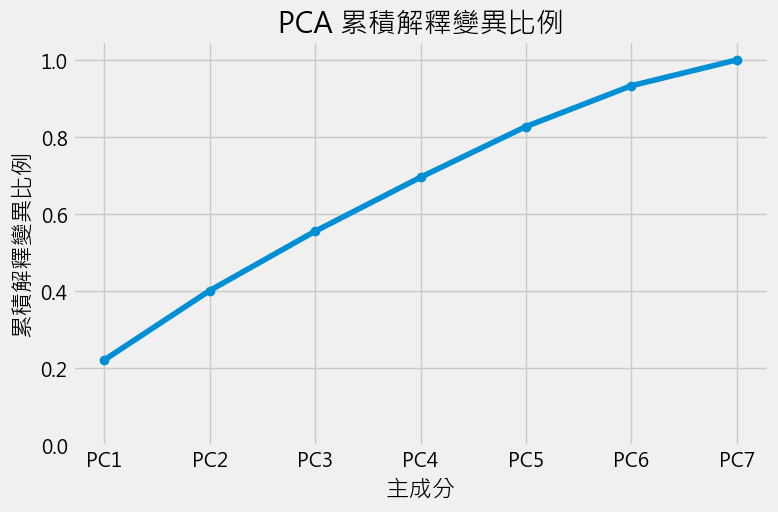

In [27]:
# ============================================================
# 10. 視覺化：PCA 累積解釋變異比例
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    explained_df['主成分'],
    explained_df['累積解釋變異比例'],
    marker='o'
)
plt.ylim(0, 1.05)
plt.xlabel('主成分')
plt.ylabel('累積解釋變異比例')
plt.title('PCA 累積解釋變異比例')
plt.grid(True)
plt.show()


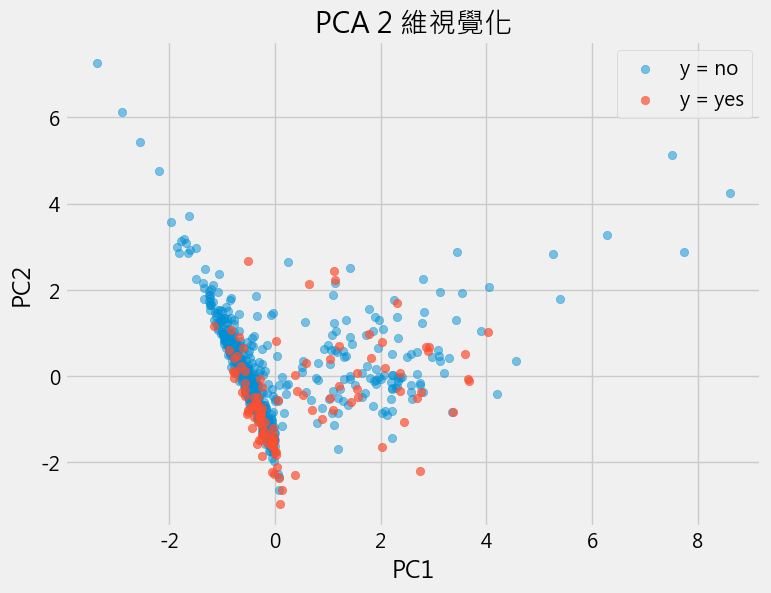

In [28]:
# ============================================================
# 11. 視覺化：PCA 2 維散佈圖
# ============================================================
# 這裡先用 y 的 yes/no 當作顏色輔助觀察。
# 注意：y 沒有被拿來訓練 PCA，只是畫圖時輔助觀察。
# ============================================================

plt.figure(figsize=(8, 6))

mask_no = pca_df['y'] == 'no'
mask_yes = pca_df['y'] == 'yes'

plt.scatter(
    pca_df.loc[mask_no, 'PC1'],
    pca_df.loc[mask_no, 'PC2'],
    alpha=0.5,
    label='y = no'
)

plt.scatter(
    pca_df.loc[mask_yes, 'PC1'],
    pca_df.loc[mask_yes, 'PC2'],
    alpha=0.7,
    label='y = yes'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2 維視覺化')
plt.legend()
plt.grid(True)
plt.show()



## 8. K-means 分群

K-means 是常見的分群方法。

它會先指定群數 $k$，再反覆調整每個資料點所屬的群，目標是讓同一群內的資料彼此更接近。

K-means 的簡化目標可以理解為：

$$
\min \sum_{j=1}^{k} \sum_{x_i \in C_j} \lVert x_i - \mu_j \rVert^2
$$

其中：

- $k$：群數
- $C_j$：第 $j$ 群
- $x_i$：第 $i$ 筆資料
- $\mu_j$：第 $j$ 群的中心點

本作業直接在 PCA 後的 2 維資料上做 K-means，這樣可以更容易畫圖檢查結果。



## 9. 使用 Silhouette Score 選擇群數

Silhouette Score 可以衡量分群結果是否合理。

分數範圍大約介於 -1 到 1：

| 分數 | 解讀 |
|---|---|
| 接近 1 | 分群效果較好，同群接近、不同群分開 |
| 接近 0 | 群與群之間界線不明顯 |
| 小於 0 | 可能分錯群 |

本作業只使用 Silhouette Score 作為分群評估指標。

教材中提到的 Distortion / SSE 也是常見指標，但本作業為了簡化不實作。


In [29]:
# ============================================================
# 12. 嘗試不同的 k，並計算 Silhouette Score
# ============================================================
# k 不能是 1，因為 Silhouette Score 需要至少 2 群。
# ============================================================

score_rows = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=5
    )

    cluster_labels = kmeans.fit_predict(pca_df[['PC1', 'PC2']])

    score = silhouette_score(
        pca_df[['PC1', 'PC2']],
        cluster_labels,
        sample_size=300,
        random_state=42
    )

    score_rows.append({
        'k': k,
        'Silhouette Score': score
    })

silhouette_df = pd.DataFrame(score_rows)

print('不同 k 值的 Silhouette Score：')
display(silhouette_df)


不同 k 值的 Silhouette Score：


,k,Silhouette Score
0,2,0.585773
1,3,0.481839
2,4,0.499616
3,5,0.486216
4,6,0.452393


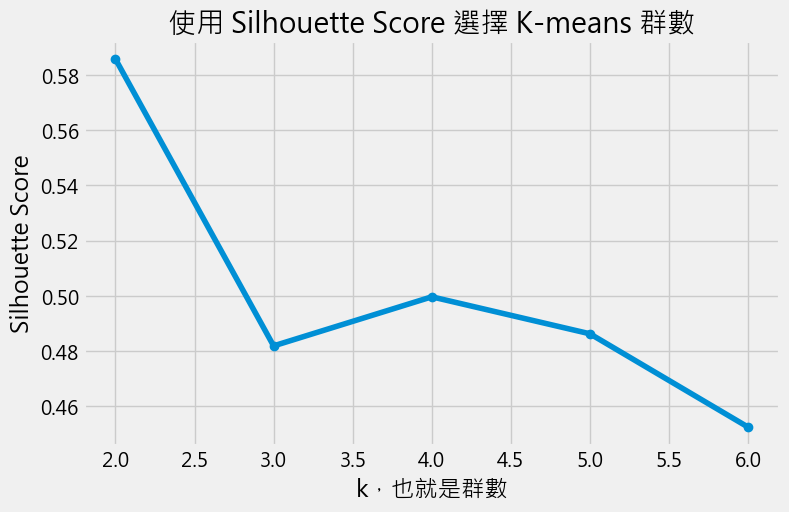

In [30]:
# ============================================================
# 13. 視覺化：不同 k 的 Silhouette Score
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_df['k'],
    silhouette_df['Silhouette Score'],
    marker='o'
)
plt.xlabel('k，也就是群數')
plt.ylabel('Silhouette Score')
plt.title('使用 Silhouette Score 選擇 K-means 群數')
plt.grid(True)
plt.show()


In [31]:
# ============================================================
# 14. 選擇 Silhouette Score 最高的 k
# ============================================================

best_row_index = silhouette_df['Silhouette Score'].idxmax()
best_k = int(silhouette_df.loc[best_row_index, 'k'])

print('本次資料中，Silhouette Score 最高的 k 是：')
print(best_k)


本次資料中，Silhouette Score 最高的 k 是：
2


In [32]:
# ============================================================
# 15. 使用最佳 k 建立 K-means 模型
# ============================================================

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=5
)

pca_df['cluster'] = final_kmeans.fit_predict(pca_df[['PC1', 'PC2']])

print('分群結果前 10 筆：')
display(pca_df.head(10))

print('\n每一群的資料筆數：')
print(pca_df['cluster'].value_counts().sort_index())


分群結果前 10 筆：


,PC1,PC2,y,cluster
0,-0.408846,-0.456066,no,0
1,-0.227735,-0.393212,no,0
2,-0.539877,-0.331747,no,0
3,2.198844,-0.527274,no,1
4,-0.621367,0.349503,no,0
5,-0.412662,-0.541076,no,0
6,-0.632349,-0.016037,no,0
7,-0.893525,0.814297,no,0
8,-0.713308,0.252584,no,0
9,-0.537795,-0.402819,no,0



每一群的資料筆數：
cluster
0    667
1    133
Name: count, dtype: int64


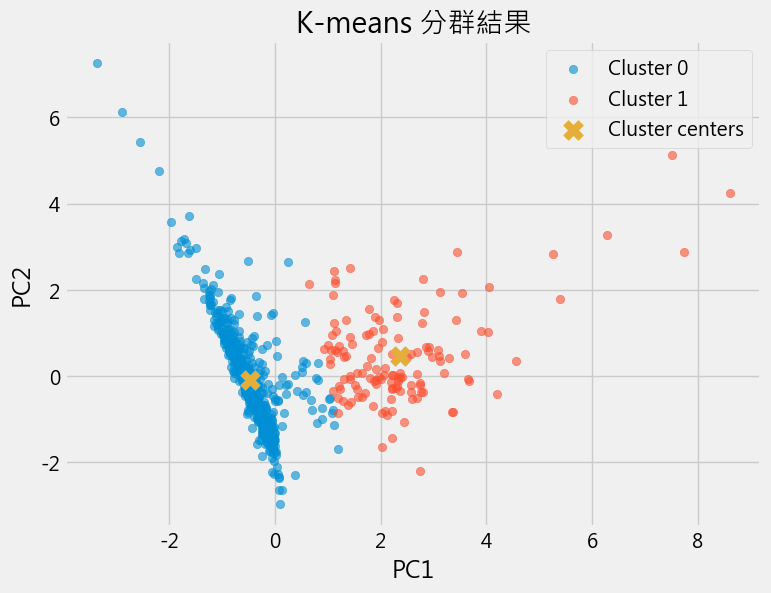

In [33]:
# ============================================================
# 16. 視覺化：K-means 分群結果
# ============================================================

plt.figure(figsize=(8, 6))

for cluster_id in sorted(pca_df['cluster'].unique()):
    mask_cluster = pca_df['cluster'] == cluster_id

    plt.scatter(
        pca_df.loc[mask_cluster, 'PC1'],
        pca_df.loc[mask_cluster, 'PC2'],
        alpha=0.6,
        label='Cluster ' + str(cluster_id)
    )

centers = final_kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=200,
    label='Cluster centers'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means 分群結果')
plt.legend()
plt.grid(True)
plt.show()



## 10. 解釋分群結果

K-means 產生的群編號本身沒有固定意義。

例如：

- Cluster 0 不一定代表「好客戶」。
- Cluster 1 不一定代表「壞客戶」。

我們需要回到原始特徵，觀察每一群的平均值，才能解釋每一群的特徵。


In [34]:
# ============================================================
# 17. 將分群結果加回原始作業資料
# ============================================================

cluster_profile = df_work.copy()
cluster_profile['cluster'] = pca_df['cluster'].values

print('每一群在數值特徵上的平均值：')
display(cluster_profile.groupby('cluster')[numeric_cols].mean())


每一群在數值特徵上的平均值：


,age,balance,day,duration,campaign,pdays,previous
cluster,,,,,,,
0,41.289355,1400.101949,15.583208,272.871064,2.823088,3.544228,0.052474
1,41.639098,1858.676692,13.902256,276.954887,2.225564,267.526316,4.210526


In [35]:
# ============================================================
# 18. 使用 y 輔助觀察每一群的申購比例
# ============================================================
# 注意：這裡只是輔助解釋，不是模型訓練。
# ============================================================

cluster_y_table = pd.crosstab(
    cluster_profile['cluster'],
    cluster_profile['y'],
    normalize='index'
)

print('每一群中 y 的比例：')
display(cluster_y_table)


每一群中 y 的比例：


y,no,yes
cluster,,
0,0.880060,0.119940
1,0.774436,0.225564



## 11. 方法比較：本作業沒有實作，但需要知道差異

| 方法 | 類型 | 本作業是否實作 | 重點說明 |
|---|---|---|---|
| PCA | 線性降維 | 有 | 將多個特徵轉成主成分，適合做視覺化與資料壓縮 |
| Kernel PCA | 非線性降維 | 沒有 | 透過 kernel 處理非線性結構，但參數較多，較不適合作為初學作業主軸 |
| K-means | 分群 | 有 | 常見、容易理解，但需要先指定群數 k |
| Hierarchical Clustering | 分群 | 沒有 | 可以用樹狀圖觀察合併過程，但資料量大時圖會很難讀 |
| DBSCAN | 分群 | 沒有 | 可以找出任意形狀的群與離群值，但 eps、min_samples 需要調整 |
| Silhouette Score | 分群評估 | 有 | 本作業採用的評估指標，分數越接近 1 通常越好 |
| Distortion / SSE | 分群評估 | 沒有 | 常搭配 Elbow Method 使用，但本作業為了簡化不實作 |



# 作業問題

請根據你執行 notebook 後得到的結果，回答以下問題。

## 第 1 題：資料理解

1. 本資料集共有幾筆資料？幾個欄位？
2. 哪些欄位是數值欄位？哪些欄位是類別欄位？
3. 為什麼本作業不使用 `y` 來訓練 PCA 與 K-means？

## 第 2 題：標準化

1. 為什麼 PCA 與 K-means 前需要先標準化？
2. 如果不標準化，可能會發生什麼問題？

## 第 3 題：PCA

1. PC1 的解釋變異比例是多少？
2. PC1 + PC2 的累積解釋變異比例是多少？
3. 根據 PCA 2 維散佈圖，你覺得 `y = yes` 和 `y = no` 是否明顯分開？請用 2 到 3 句話說明。

## 第 4 題：K-means 與 Silhouette Score

1. 在本次結果中，Silhouette Score 最高的 k 是多少？
2. 這個最高分數大約是多少？
3. 你認為這代表分群效果很好、普通，還是不明顯？請說明理由。

## 第 5 題：分群解釋

請觀察「每一群在數值特徵上的平均值」，選擇其中兩個 cluster，說明它們可能有什麼差異。

可以參考以下特徵：

- age
- balance
- duration
- campaign
- pdays
- previous

## 第 6 題：方法比較

請用自己的話簡短回答：

1. PCA 與 Kernel PCA 的差異是什麼？
2. K-means、階層式分群、DBSCAN 的差異是什麼？
3. 為什麼本作業選擇 K-means 作為主要分群方法？

## 加分題

請修改 `numeric_cols`，嘗試拿掉 `duration`，再重新執行 PCA 與 K-means。

回答：

1. 拿掉 `duration` 後，Silhouette Score 是否改變？
2. PCA 2 維散佈圖是否看起來不同？
3. 你認為 `duration` 對分群結果影響大嗎？為什麼？
